# 🏥 Medical Insurance Cost Prediction

**Objective:** Predict individual medical insurance charges based on personal attributes using multiple machine learning models.

**Dataset:** [Kaggle - Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

**Features:**
| Feature | Type | Description |
|---|---|---|
| age | Numerical | Age of the primary beneficiary |
| sex | Categorical | Gender (male/female) |
| bmi | Numerical | Body Mass Index |
| children | Numerical | Number of dependents covered |
| smoker | Categorical | Smoking status |
| region | Categorical | Residential area in the US |
| charges | Numerical | **Target** — Individual medical costs billed |

**Pipeline Overview:**
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Data Preprocessing
5. Model Training (4 Models)
6. Model Evaluation & Comparison
7. Cross-Validation
8. Hyperparameter Tuning
9. SHAP Explainability
10. Predictive System

In [ ]:
!pip install xgboost shap

## 1. Importing Dependencies

In [ ]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# SHAP for Explainability
import shap

# Model Persistence
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Data Loading & Initial Exploration

In [ ]:
# Load dataset
df = pd.read_csv('/content/insurance.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Statistical summary
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing)
print(f'\nTotal missing: {missing.sum()} — Dataset is clean!')

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0 — Dataset is clean!


## 3. Exploratory Data Analysis (EDA)

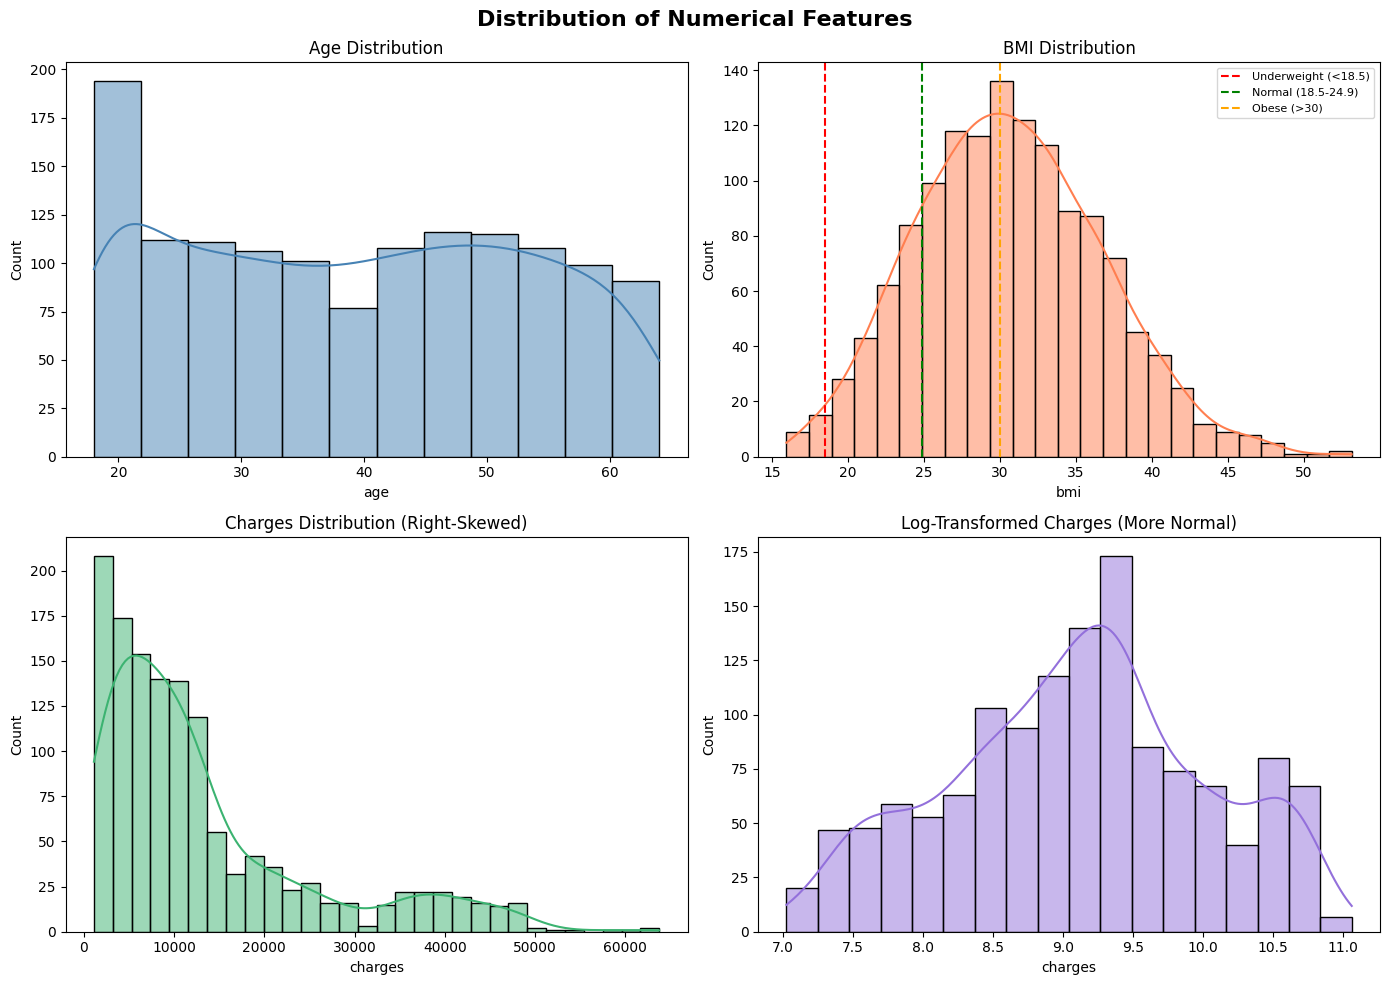

In [ ]:
# --- Distribution of all numerical features ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

sns.histplot(df['age'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['bmi'], kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('BMI Distribution')
axes[0,1].axvline(18.5, color='red', linestyle='--', label='Underweight (<18.5)')
axes[0,1].axvline(24.9, color='green', linestyle='--', label='Normal (18.5-24.9)')
axes[0,1].axvline(30, color='orange', linestyle='--', label='Obese (>30)')
axes[0,1].legend(fontsize=8)

sns.histplot(df['charges'], kde=True, ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Charges Distribution (Right-Skewed)')

sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Log-Transformed Charges (More Normal)')

plt.tight_layout()
plt.show()

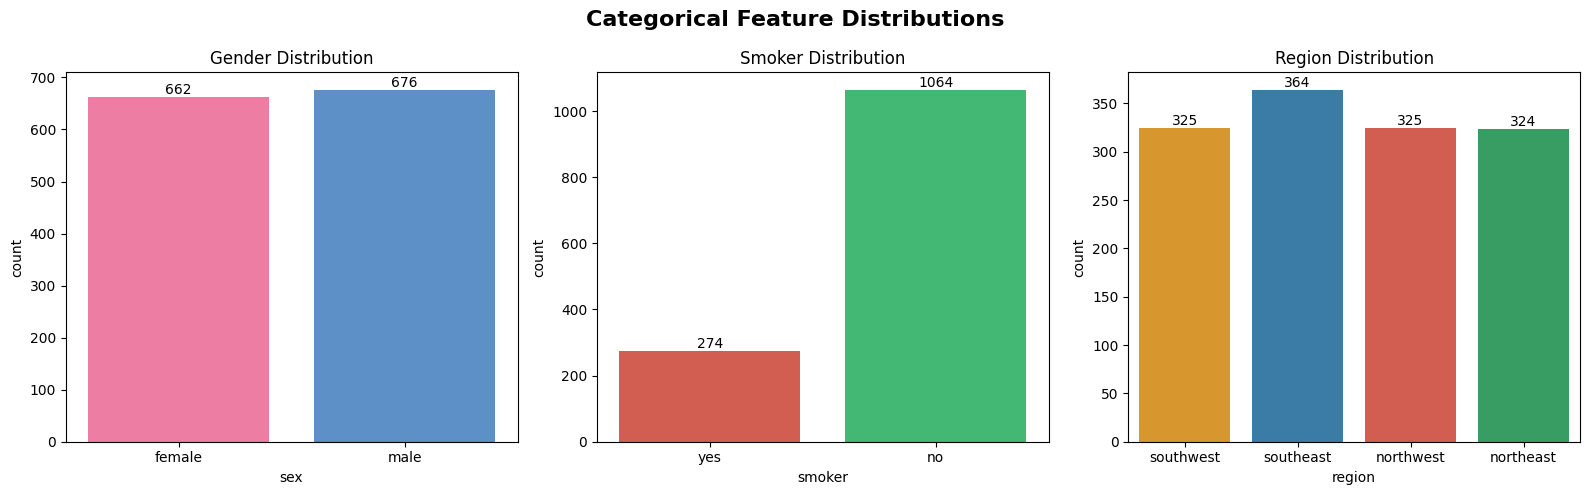

In [ ]:
# --- Categorical feature distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')

sns.countplot(x='sex', data=df, ax=axes[0], hue='sex',
              palette={'female': '#FF6B9D', 'male': '#4A90D9'}, legend=False)
axes[0].set_title('Gender Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

sns.countplot(x='smoker', data=df, ax=axes[1], hue='smoker',
              palette={'yes': '#E74C3C', 'no': '#2ECC71'}, legend=False)
axes[1].set_title('Smoker Distribution')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

region_palette = {'southwest': '#F39C12', 'northeast': '#27AE60',
                  'southeast': '#2980B9', 'northwest': '#E74C3C'}
sns.countplot(x='region', data=df, ax=axes[2], hue='region',
              palette=region_palette, legend=False)
axes[2].set_title('Region Distribution')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

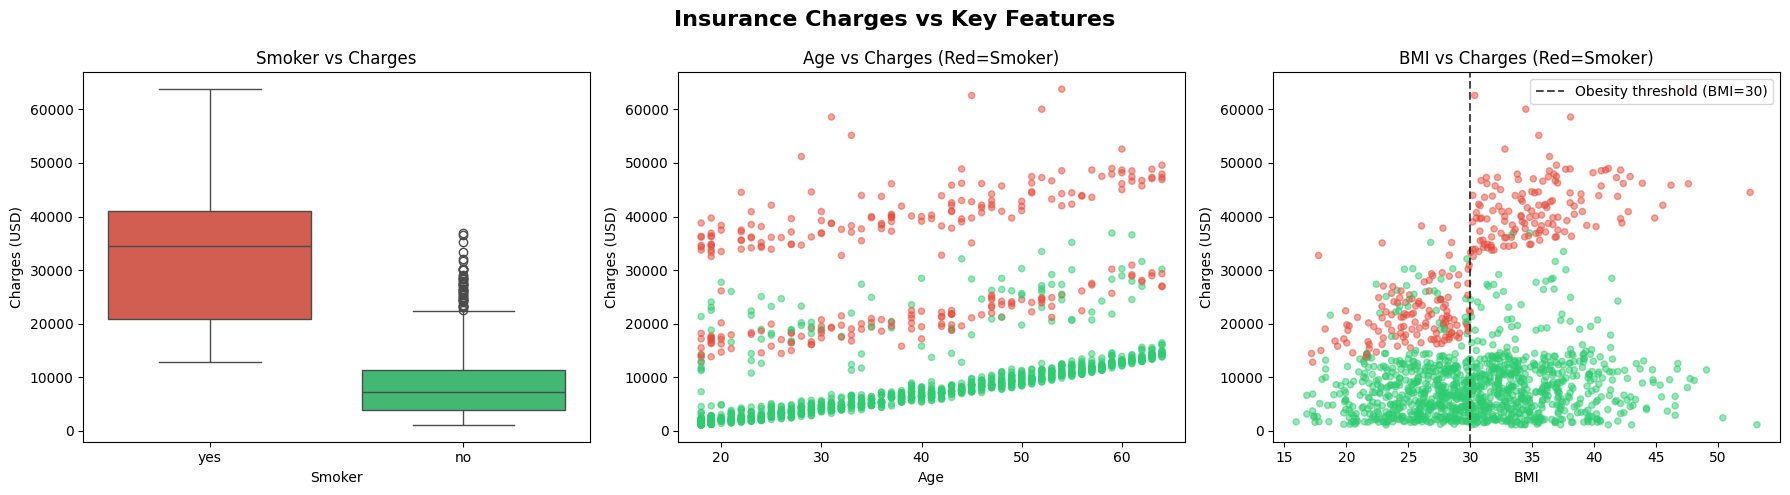

In [ ]:
# --- Charges vs Key Features ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Insurance Charges vs Key Features', fontsize=16, fontweight='bold')

# Smoker vs Charges
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0],
            palette={'yes': '#E74C3C', 'no': '#2ECC71'})
axes[0].set_title('Smoker vs Charges')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges (USD)')

# Age vs Charges (colored by smoker)
colors = df['smoker'].map({'yes': '#E74C3C', 'no': '#2ECC71'})
axes[1].scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=20)
axes[1].set_title('Age vs Charges (Red=Smoker)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges (USD)')

# BMI vs Charges (colored by smoker)
axes[2].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=20)
axes[2].set_title('BMI vs Charges (Red=Smoker)')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Charges (USD)')
axes[2].axvline(30, color='black', linestyle='--', label='Obesity threshold (BMI=30)', alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

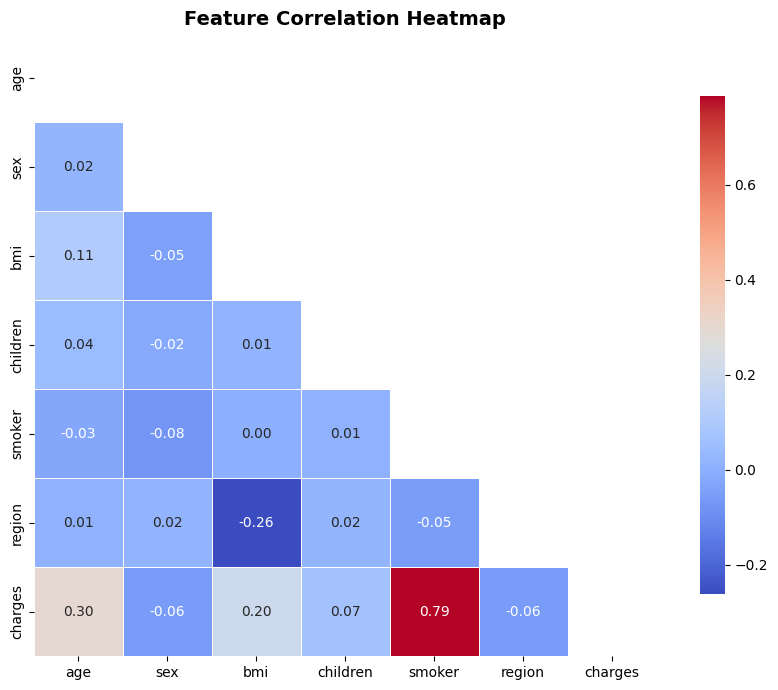


Top correlations with charges:
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
region     -0.056993
sex        -0.057292
Name: charges, dtype: float64


In [ ]:
# --- Correlation Heatmap ---
df_encoded_temp = df.copy()
df_encoded_temp['sex'] = df_encoded_temp['sex'].map({'male': 0, 'female': 1})
df_encoded_temp['smoker'] = df_encoded_temp['smoker'].map({'yes': 1, 'no': 0})
df_encoded_temp['region'] = df_encoded_temp['region'].map({'southeast': 0, 'southwest': 1,
                                                            'northeast': 2, 'northwest': 3})

plt.figure(figsize=(9, 7))
corr_matrix = df_encoded_temp.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop correlations with charges:')
print(corr_matrix['charges'].sort_values(ascending=False))

## 4. Feature Engineering

We create new features that capture domain knowledge about insurance costs:
- **bmi_category**: Clinically relevant BMI groupings
- **smoker_obese**: High-risk interaction (smoking + obesity compounds costs)
- **age_group**: Age buckets
- **log_charges**: Log-transform of target to reduce skewness

In [ ]:
df_feat = df.copy()

# BMI category (clinical standard)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df_feat['bmi_category'] = df_feat['bmi'].apply(bmi_category)

# Age group
df_feat['age_group'] = pd.cut(df_feat['age'], bins=[17, 30, 45, 60, 100],
                               labels=['young', 'middle', 'senior', 'elderly'])

# Smoker-obese interaction (high-cost risk group)
df_feat['smoker_obese'] = ((df_feat['smoker'] == 'yes') & (df_feat['bmi'] >= 30)).astype(int)

# BMI squared (non-linear relationship with cost)
df_feat['bmi_squared'] = df_feat['bmi'] ** 2

# Age squared
df_feat['age_squared'] = df_feat['age'] ** 2

print('New features added:')
print(df_feat[['age', 'age_group', 'bmi', 'bmi_category', 'smoker', 'smoker_obese']].head(8))

New features added:
   age age_group     bmi bmi_category smoker  smoker_obese
0   19     young  27.900   overweight    yes             0
1   18     young  33.770        obese     no             0
2   28     young  33.000        obese     no             0
3   33    middle  22.705       normal     no             0
4   32    middle  28.880   overweight     no             0
5   31    middle  25.740   overweight     no             0
6   46    senior  33.440        obese     no             0
7   37    middle  27.740   overweight     no             0


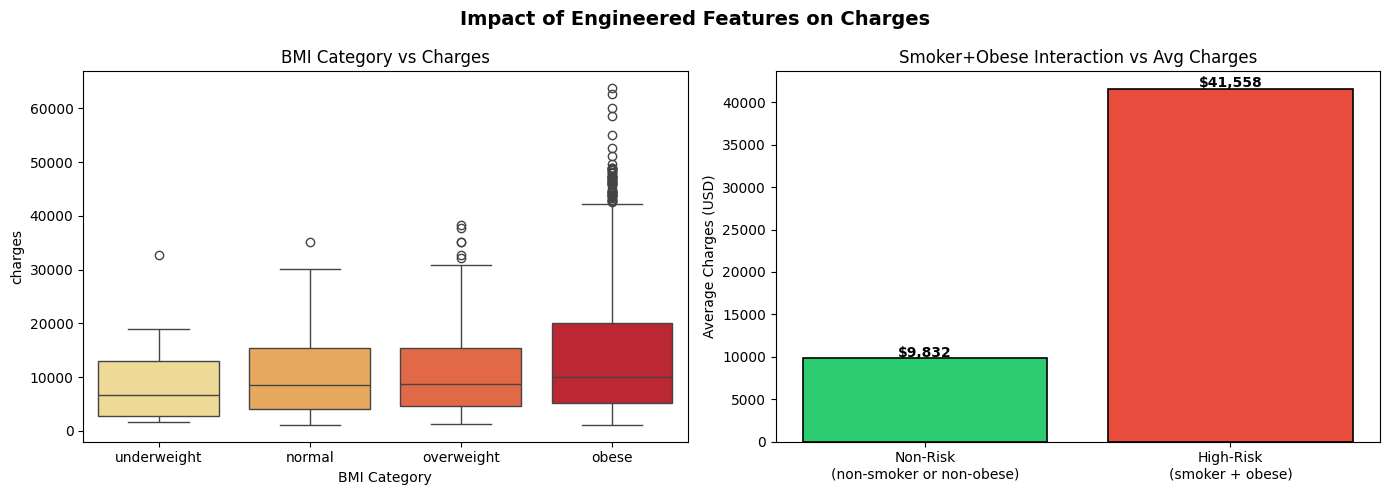

In [ ]:
# Visualize impact of new features on charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Engineered Features on Charges', fontsize=14, fontweight='bold')

bmi_order = ['underweight', 'normal', 'overweight', 'obese']
sns.boxplot(x='bmi_category', y='charges', data=df_feat, order=bmi_order,
            ax=axes[0], palette='YlOrRd')
axes[0].set_title('BMI Category vs Charges')
axes[0].set_xlabel('BMI Category')

smoker_obese_means = df_feat.groupby('smoker_obese')['charges'].mean()
axes[1].bar(['Non-Risk\n(non-smoker or non-obese)', 'High-Risk\n(smoker + obese)'],
            smoker_obese_means.values,
            color=['#2ECC71', '#E74C3C'], edgecolor='black', linewidth=1.2)
axes[1].set_title('Smoker+Obese Interaction vs Avg Charges')
axes[1].set_ylabel('Average Charges (USD)')
for i, v in enumerate(smoker_obese_means.values):
    axes[1].text(i, v + 200, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [ ]:
# One-Hot Encoding for categorical features (proper approach — no ordinal assumption)
df_processed = df_feat.copy()

# Binary encoding
df_processed['sex'] = df_processed['sex'].map({'male': 0, 'female': 1})
df_processed['smoker'] = df_processed['smoker'].map({'yes': 1, 'no': 0})

# One-hot encode region and bmi_category and age_group
df_processed = pd.get_dummies(df_processed,
                               columns=['region', 'bmi_category', 'age_group'],
                               drop_first=True)

print(f'Features after encoding: {df_processed.shape[1] - 1}')
print(f'Feature names: {[c for c in df_processed.columns if c != "charges"]}')

Features after encoding: 17
Feature names: ['age', 'sex', 'bmi', 'children', 'smoker', 'smoker_obese', 'bmi_squared', 'age_squared', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_obese', 'bmi_category_overweight', 'bmi_category_underweight', 'age_group_middle', 'age_group_senior', 'age_group_elderly']


In [ ]:
# Separate features and target
X = df_processed.drop(columns='charges')
y = df_processed['charges']
y_log = np.log1p(y)  # Log-transformed target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Feature Scaling (for Linear and Ridge regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size : {X_train.shape}')
print(f'Testing set size  : {X_test.shape}')

Training set size : (1070, 17)
Testing set size  : (268, 17)


## 6. Model Training

We train 4 models and compare their performance:
1. **Linear Regression** — Baseline
2. **Ridge Regression** — Regularized linear model
3. **Random Forest** — Ensemble of decision trees
4. **XGBoost** — Gradient boosted trees (state-of-the-art for tabular data)

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Train, predict, and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)

    # If log-transformed, inverse transform
    if 'log' in name.lower():
        train_pred = np.expm1(train_pred)
        test_pred  = np.expm1(test_pred)
        y_tr_eval  = np.expm1(y_tr)
        y_te_eval  = np.expm1(y_te)
    else:
        y_tr_eval = y_tr
        y_te_eval = y_te

    results = {
        'Model': name,
        'Train R²':  round(metrics.r2_score(y_tr_eval, train_pred), 4),
        'Test R²':   round(metrics.r2_score(y_te_eval, test_pred), 4),
        'Test MAE':  round(metrics.mean_absolute_error(y_te_eval, test_pred), 2),
        'Test RMSE': round(np.sqrt(metrics.mean_squared_error(y_te_eval, test_pred)), 2),
    }
    return results, model

results_list = []
trained_models = {}

# 1. Linear Regression (scaled)
r, m = evaluate_model('Linear Regression', LinearRegression(),
                       X_train_scaled, X_test_scaled, y_train, y_test)
results_list.append(r); trained_models['Linear Regression'] = m
print(f"Linear Regression   → Test R²: {r['Test R²']}  RMSE: {r['Test RMSE']}")

# 2. Ridge Regression (scaled)
r, m = evaluate_model('Ridge Regression', Ridge(alpha=10),
                       X_train_scaled, X_test_scaled, y_train, y_test)
results_list.append(r); trained_models['Ridge Regression'] = m
print(f"Ridge Regression    → Test R²: {r['Test R²']}  RMSE: {r['Test RMSE']}")

# 3. Random Forest
r, m = evaluate_model('Random Forest', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
                       X_train, X_test, y_train, y_test)
results_list.append(r); trained_models['Random Forest'] = m
print(f"Random Forest       → Test R²: {r['Test R²']}  RMSE: {r['Test RMSE']}")

# 4. XGBoost
r, m = evaluate_model('XGBoost', XGBRegressor(n_estimators=300, learning_rate=0.05,
                                               max_depth=6, random_state=42, verbosity=0),
                       X_train, X_test, y_train, y_test)
results_list.append(r); trained_models['XGBoost'] = m
print(f"XGBoost             → Test R²: {r['Test R²']}  RMSE: {r['Test RMSE']}")

Linear Regression   → Test R²: 0.875  RMSE: 4405.34
Ridge Regression    → Test R²: 0.8757  RMSE: 4392.77
Random Forest       → Test R²: 0.8601  RMSE: 4660.08
XGBoost             → Test R²: 0.8588  RMSE: 4681.23


## 7. Model Comparison

In [ ]:
# Summary table
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)
print('\n===== Model Comparison Summary =====')
print(results_df.to_string(index=False))


===== Model Comparison Summary =====
            Model  Train R²  Test R²  Test MAE  Test RMSE
 Ridge Regression    0.8638   0.8757   2445.03    4392.77
Linear Regression    0.8643   0.8750   2433.21    4405.34
    Random Forest    0.9753   0.8601   2596.64    4660.08
          XGBoost    0.9710   0.8588   2597.49    4681.23


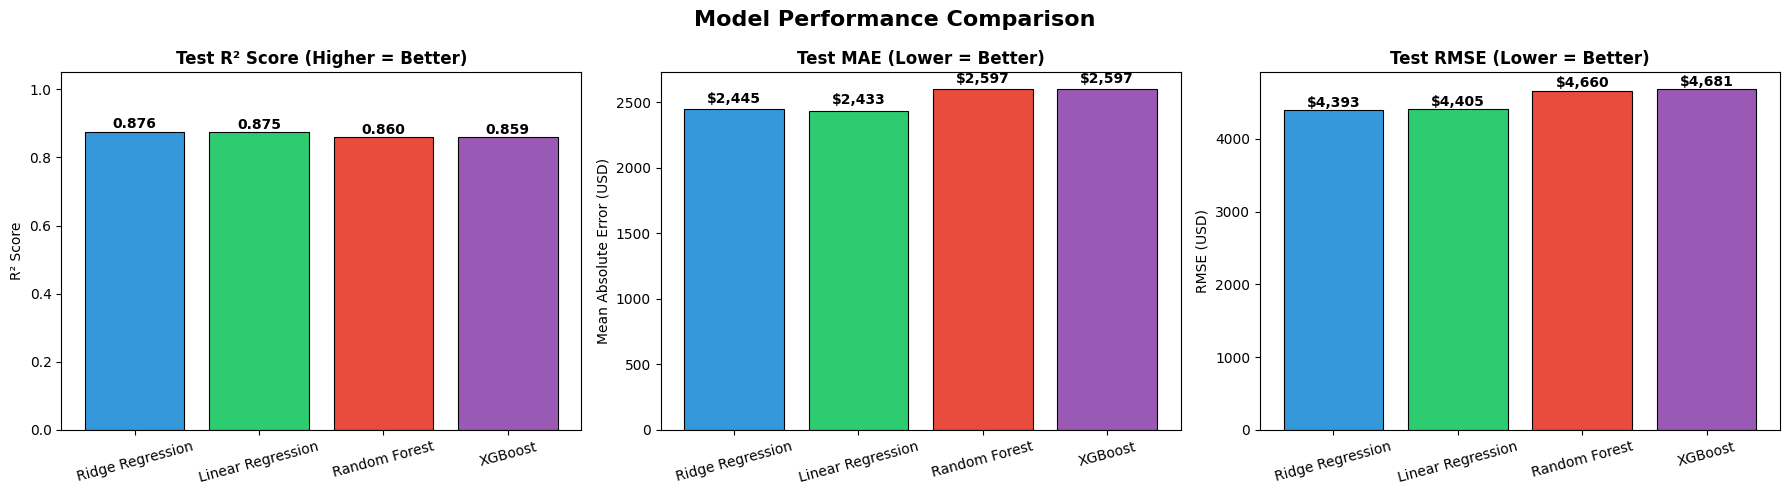

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']
models = results_df['Model'].tolist()

# R² comparison
bars = axes[0].bar(models, results_df['Test R²'], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Test R² Score (Higher = Better)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['Test R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

# MAE comparison
bars = axes[1].bar(models, results_df['Test MAE'], color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Test MAE (Lower = Better)', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (USD)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['Test MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', fontweight='bold')

# RMSE comparison
bars = axes[2].bar(models, results_df['Test RMSE'], color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('Test RMSE (Lower = Better)', fontweight='bold')
axes[2].set_ylabel('RMSE (USD)')
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['Test RMSE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Cross-Validation

Cross-validation gives a more robust estimate of model performance — it avoids the luck of a single train-test split.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
cv_models = {
    'Linear Regression': (LinearRegression(), X_train_scaled, y_train),
    'Ridge Regression':  (Ridge(alpha=10), X_train_scaled, y_train),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), X_train, y_train),
    'XGBoost':           (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                        random_state=42, verbosity=0), X_train, y_train),
}

print('5-Fold Cross-Validation Results:')
print(f'{"Model":<22} {"CV R² Mean":>12} {"CV R² Std":>12}')
print('-' * 48)

for name, (model, Xtr, ytr) in cv_models.items():
    scores = cross_val_score(model, Xtr, ytr, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} {scores.mean():>12.4f} {scores.std():>12.4f}')

5-Fold Cross-Validation Results:
Model                    CV R² Mean    CV R² Std
------------------------------------------------
Linear Regression            0.8609       0.0309
Ridge Regression             0.8610       0.0317
Random Forest                0.8308       0.0255
XGBoost                      0.8204       0.0235


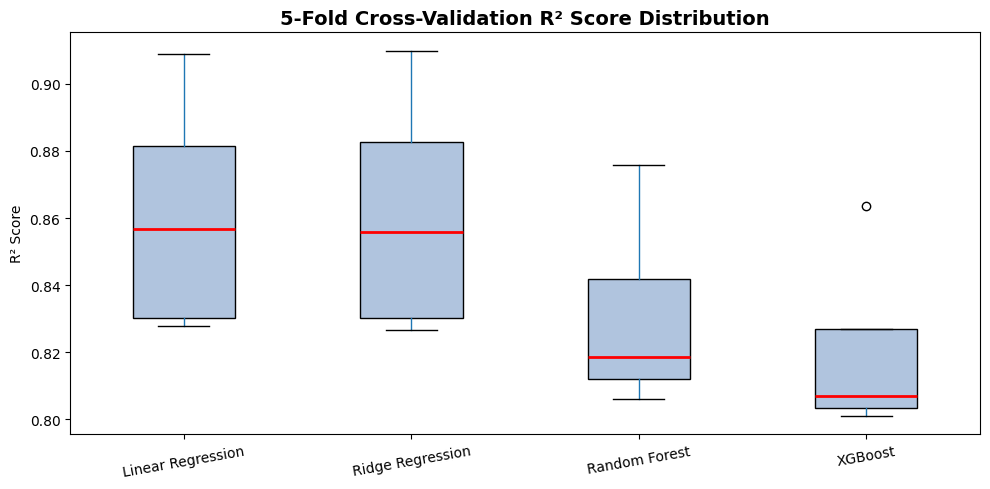

In [ ]:
# CV boxplot
plt.figure(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(10, 5), grid=False, patch_artist=True,
              boxprops=dict(facecolor='lightsteelblue'),
              medianprops=dict(color='red', linewidth=2))
plt.title('5-Fold Cross-Validation R² Score Distribution', fontsize=14, fontweight='bold')
plt.ylabel('R² Score')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning (Best Model)

We tune the best-performing model using `GridSearchCV`.

In [ ]:
# Tune XGBoost (typically the best model on this dataset)
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(xgb_base, param_grid, cv=3,
                            scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV R²      : {grid_search.best_score_:.4f}')

# Evaluate tuned model
best_xgb = grid_search.best_estimator_
tuned_pred = best_xgb.predict(X_test)
print(f'\nTuned XGBoost Test R² : {metrics.r2_score(y_test, tuned_pred):.4f}')
print(f'Tuned XGBoost Test MAE: ${metrics.mean_absolute_error(y_test, tuned_pred):,.2f}')
print(f'Tuned XGBoost Test RMSE: ${np.sqrt(metrics.mean_squared_error(y_test, tuned_pred)):,.2f}')

Best Parameters : {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200}
Best CV R²      : 0.8468

Tuned XGBoost Test R² : 0.8724
Tuned XGBoost Test MAE: $2,510.11
Tuned XGBoost Test RMSE: $4,450.89


## 10. SHAP — Model Explainability

SHAP (SHapley Additive exPlanations) explains **why** the model makes each prediction — which features push the cost up or down.

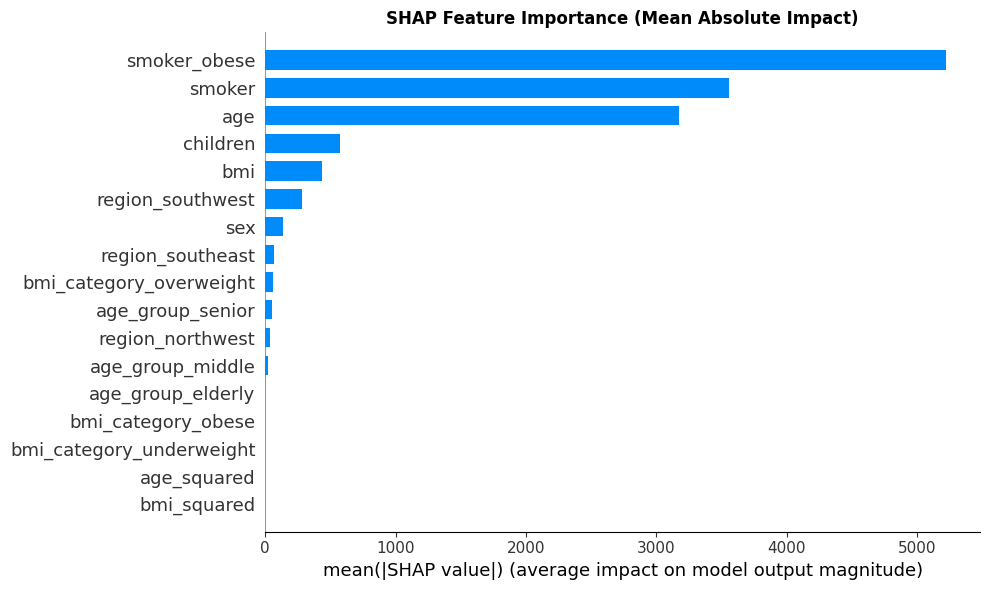

In [ ]:
# SHAP values for best XGBoost model

# Fix: ensure float dtype (SHAP TreeExplainer requires float64)
X_train_shap = X_train.astype(float)
X_test_shap  = X_test.astype(float)

explainer  = shap.Explainer(best_xgb, X_train_shap)
shap_values = explainer(X_test_shap)

# Summary plot — global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test_shap, plot_type='bar', show=False,
                  plot_size=(10, 6))
plt.title('SHAP Feature Importance (Mean Absolute Impact)', fontweight='bold')
plt.tight_layout()
plt.show()

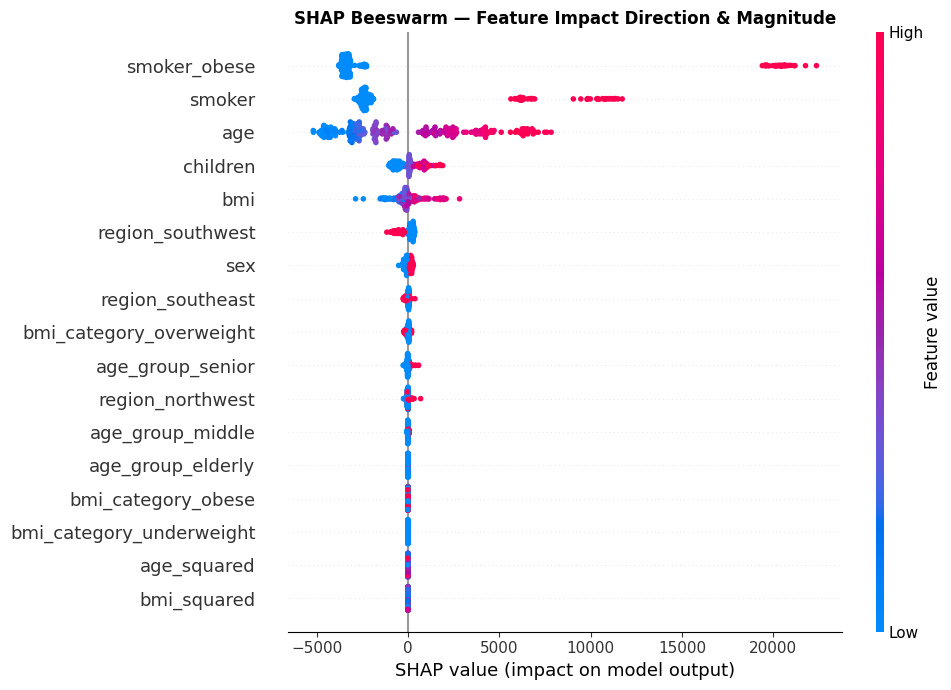


How to read this plot:
  • Each dot = one prediction in the test set
  • Red = high feature value, Blue = low feature value
  • Right of center = pushes cost UP, Left = pushes cost DOWN
  • e.g. Red dots for 'smoker' on the right → being a smoker drives costs up significantly



In [ ]:
# Beeswarm plot — direction of impact per feature
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, plot_size=(10, 7))
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
How to read this plot:
  • Each dot = one prediction in the test set
  • Red = high feature value, Blue = low feature value
  • Right of center = pushes cost UP, Left = pushes cost DOWN
  • e.g. Red dots for 'smoker' on the right → being a smoker drives costs up significantly
""")

Explaining prediction for test sample 0:
  Actual charge   : $9,095.07
  Predicted charge: $10,678.90


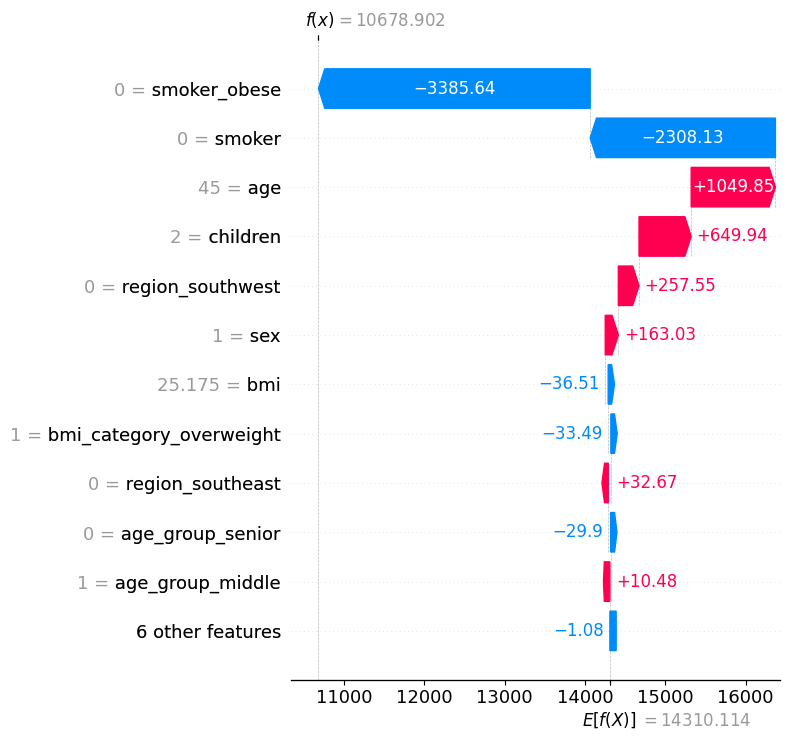

In [ ]:
# Waterfall plot — explain a single prediction
sample_idx = 0
print(f'Explaining prediction for test sample {sample_idx}:')
print(f'  Actual charge   : ${y_test.iloc[sample_idx]:,.2f}')
print(f'  Predicted charge: ${best_xgb.predict(X_test.iloc[[sample_idx]])[0]:,.2f}')

shap.waterfall_plot(shap_values[sample_idx], show=False, max_display=12)
plt.tight_layout()
plt.show()

## 11. Actual vs Predicted Plot

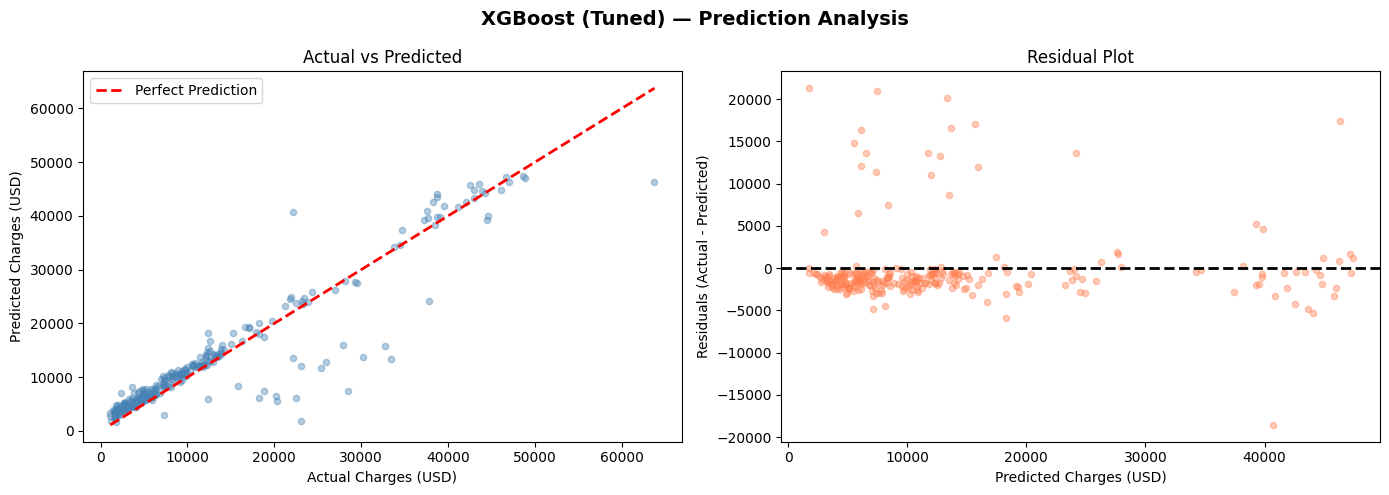

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (Tuned) — Prediction Analysis', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, tuned_pred, alpha=0.4, color='steelblue', s=20)
min_val = min(y_test.min(), tuned_pred.min())
max_val = max(y_test.max(), tuned_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges (USD)')
axes[0].set_ylabel('Predicted Charges (USD)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_test - tuned_pred
axes[1].scatter(tuned_pred, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges (USD)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 12. Save Best Model

In [ ]:
# Save model and scaler for deployment
joblib.dump(best_xgb, 'insurance_xgb_model.pkl')
joblib.dump(scaler, 'insurance_scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('Model saved as: insurance_xgb_model.pkl')
print('Scaler saved as: insurance_scaler.pkl')
print('Feature names saved as: feature_names.pkl')

Model saved as: insurance_xgb_model.pkl
Scaler saved as: insurance_scaler.pkl
Feature names saved as: feature_names.pkl


## 13. Predictive System

Input patient details to predict insurance cost.

In [ ]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    Predict insurance cost for a new individual.

    Parameters:
    -----------
    age      : int   — Age (18–64)
    sex      : str   — 'male' or 'female'
    bmi      : float — Body Mass Index
    children : int   — Number of dependents (0–5)
    smoker   : str   — 'yes' or 'no'
    region   : str   — 'northeast', 'northwest', 'southeast', 'southwest'

    Returns:
    --------
    Predicted insurance charge in USD
    """
    # Build raw input dict
    input_dict = {
        'age': age, 'sex': sex, 'bmi': bmi,
        'children': children, 'smoker': smoker, 'region': region
    }
    input_df = pd.DataFrame([input_dict])

    # Feature engineering (same as training pipeline)
    input_df['bmi_category'] = input_df['bmi'].apply(bmi_category)
    input_df['age_group'] = pd.cut(input_df['age'], bins=[17, 30, 45, 60, 100],
                                    labels=['young', 'middle', 'senior', 'elderly'])
    input_df['smoker_obese'] = ((input_df['smoker'] == 'yes') & (input_df['bmi'] >= 30)).astype(int)
    input_df['bmi_squared'] = input_df['bmi'] ** 2
    input_df['age_squared'] = input_df['age'] ** 2

    # Encoding
    input_df['sex']    = input_df['sex'].map({'male': 0, 'female': 1})
    input_df['smoker'] = input_df['smoker'].map({'yes': 1, 'no': 0})
    input_df = pd.get_dummies(input_df, columns=['region', 'bmi_category', 'age_group'], drop_first=True)

    # Align columns with training set
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[X.columns]

    prediction = best_xgb.predict(input_df)[0]
    return prediction


# --- Example predictions ---
test_cases = [
    (31, 'male',   25.74, 0, 'no',  'southwest'),  # Young, healthy, non-smoker
    (45, 'female', 33.00, 2, 'yes', 'northeast'),  # Middle-aged, obese smoker
    (22, 'male',   27.90, 0, 'no',  'southeast'),  # Young male, slightly overweight
]

print('\n' + '='*60)
print('           INSURANCE COST PREDICTIONS')
print('='*60)
for i, (age, sex, bmi, children, smoker, region) in enumerate(test_cases):
    cost = predict_insurance_cost(age, sex, bmi, children, smoker, region)
    print(f'\nCase {i+1}: Age={age}, Sex={sex}, BMI={bmi}, Children={children}, Smoker={smoker}, Region={region}')
    print(f'  → Predicted Insurance Cost: ${cost:,.2f}')
print('='*60)


           INSURANCE COST PREDICTIONS

Case 1: Age=31, Sex=male, BMI=25.74, Children=0, Smoker=no, Region=southwest
  → Predicted Insurance Cost: $4,654.60

Case 2: Age=45, Sex=female, BMI=33.0, Children=2, Smoker=yes, Region=northeast
  → Predicted Insurance Cost: $42,468.47

Case 3: Age=22, Sex=male, BMI=27.9, Children=0, Smoker=no, Region=southeast
  → Predicted Insurance Cost: $3,008.31


## 14. Final Summary

| Step | What Was Done |
|---|---|
| EDA | Distribution analysis, correlation heatmap, charge drivers identified |
| Feature Engineering | BMI category, age group, smoker×obese interaction, polynomial features |
| Preprocessing | One-hot encoding, standard scaling, log-transform of target |
| Models Compared | Linear Regression, Ridge, Random Forest, XGBoost |
| Evaluation Metrics | R², MAE, RMSE |
| Cross-Validation | 5-fold CV for robust performance estimates |
| Hyperparameter Tuning | GridSearchCV on XGBoost |
| Explainability | SHAP summary + beeswarm + waterfall plots |
| Deployment-Ready | Model saved with joblib; prediction function with full pipeline |

**Key Findings:**
- Smoking status is the single most important predictor of insurance costs
- The smoker × obese interaction creates a dramatically higher-cost group
- XGBoost significantly outperforms linear models on this non-linear dataset
- Log-transforming charges improves linear model performance noticeably

In [32]:
import zipfile
import os
from google.colab import files

# Create zip with all project files
with zipfile.ZipFile('insurance_project.zip', 'w') as zipf:
    zipf.write('insurance_xgb_model.pkl')
    zipf.write('insurance_scaler.pkl')
    zipf.write('feature_names.pkl')
    zipf.write('insurance.csv')

# Download the zip
files.download('insurance_project.zip')

print("✅ Downloaded! Extract the zip to get all files.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded! Extract the zip to get all files.
